In [33]:
from pathlib import Path

import confnotebook

source = Path("../examples/RPA-6542")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")


[0] 18470938
[1] 18470982
[2] 18548791
[3] 18561292
[4] 18561867
[5] 18639563
[6] 18660877
[7] 18667876
[8] 18667914
[9] 18668755
[10] 18674893
[11] 18687424
[12] 18690095
[13] 18690959
[14] 18692621
[15] 18699963
[16] 18892339
[17] 18892958
[18] 18892969
[19] 18897098
[20] 7-1
[21] [Untitled]_23-48
[22] [Untitled]_38-48


In [34]:
IDX_FILE = 1
NUM_PAGE = 0

DEBUG = True

In [35]:
from vision_core.loader.pdf_loader import PDFLoader
from vision_core.pipelines.build_document import DocumentBuildPipeline
from vision_core.preprocessor.image_orientation import PageOrientationPreprocessor

build_pipeline = DocumentBuildPipeline()

img = PDFLoader(pdf_bytes=files[IDX_FILE].read_bytes()).get_page_image(page_num=NUM_PAGE, dpi=200)

img, _ = PageOrientationPreprocessor().process(img)
ocr_results, _ = build_pipeline._run_ocr(img)

Creating model: ('PP-OCRv5_server_det', '/mnt/data/projects/rusal_recon_srv/repo/recon_vision/models/PP-OCRv5_server_det')
Creating model: ('cyrillic_PP-OCRv5_mobile_rec', '/mnt/data/projects/rusal_recon_srv/repo/recon_vision/models/cyrillic_PP-OCRv5_mobile_rec')
2026-07-22 00:34:24.268 | DEBUG    | vision_core.preprocessor.image_orientation:process:44 - Ориентация страницы: 180° с точностью 0.7768
2026-07-22 00:34:24.283 | DEBUG    | vision_core.preprocessor.image_orientation:compute_deskew_angle:116 - Углы наклона страницы: -0.7157°
2026-07-22 00:34:24.790 | DEBUG    | vision_core.pipelines.build_document:_run_ocr:237 - OCR: распознано 259 блоков, средняя уверенность: 0.95


In [36]:
from vision_core.detector.table_detector import TableDetector

detector = TableDetector(ocr_engine=build_pipeline.ocr_engine)

_ = detector.detect_tables(img, ocr_results, NUM_PAGE)

Resized image size (4486x64) exceeds max_side_limit of 4000. Resizing to fit within limit.


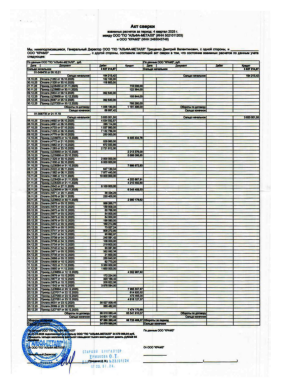

In [37]:
from matplotlib import pyplot as plt

if DEBUG:
    plt.imshow(detector._sharpness_img)
    plt.axis("off")
    plt.show()

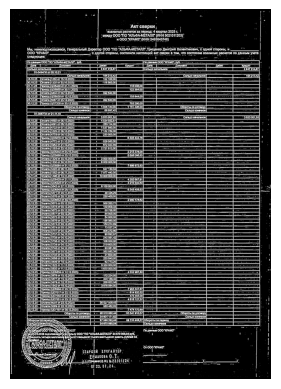

In [38]:
if DEBUG:
    plt.imshow(detector._binary_img, cmap="gray")
    plt.axis("off")
    plt.show()

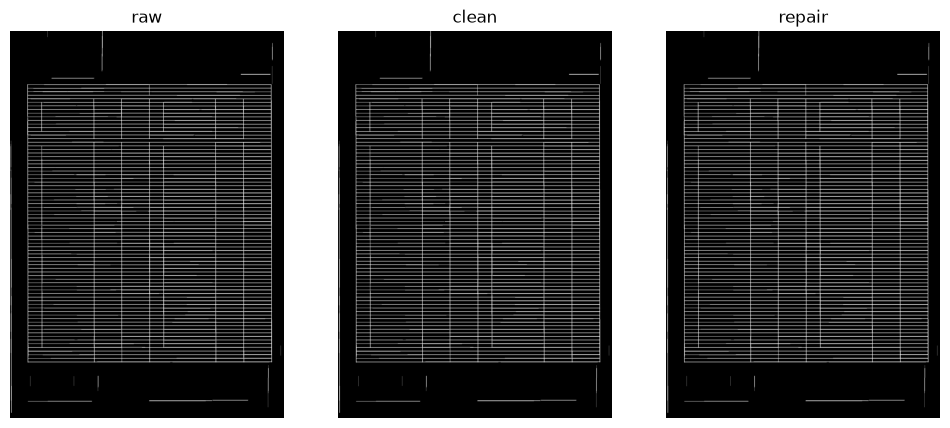

In [39]:
if DEBUG:
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))

    axes[0].imshow(detector._mask_raw_lines, cmap="gray")
    axes[0].set_title("raw")
    axes[0].axis("off")

    axes[1].imshow(detector._mask_clean_lines, cmap="gray")
    axes[1].set_title("clean")
    axes[1].axis("off")

    axes[2].imshow(detector._mask_fixed, cmap="gray")
    axes[2].set_title("repair")
    axes[2].axis("off")

    plt.show()

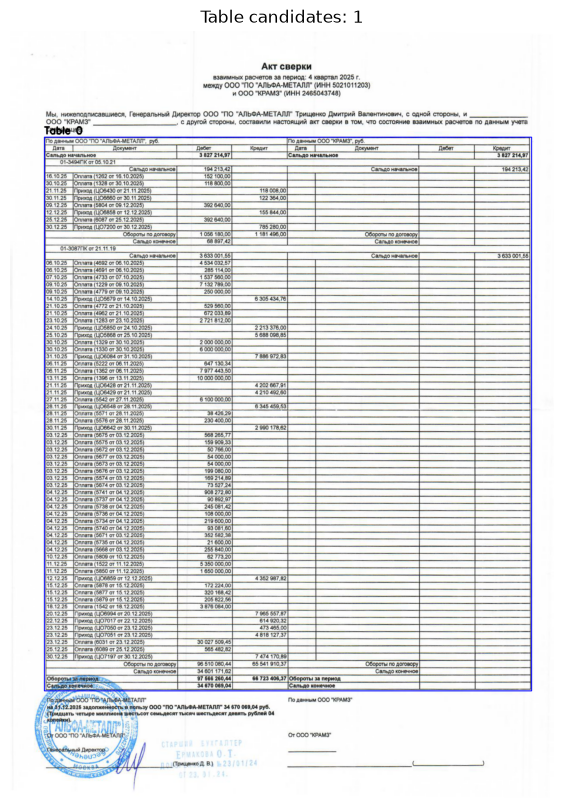

In [40]:
import cv2

table_candidates = detector._find_table_candidates(detector.ocr_bboxes)

vis = img.copy()
for i, bbox in enumerate(table_candidates):
    x, y, w, h = bbox.to_tuple()
    cv2.putText(vis, f"Table {i}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 3)
    cv2.rectangle(vis, (x, y), (w, h), (0, 0, 255), 2)
plt.figure(figsize=(10, 10))
plt.imshow(vis)
plt.title(f"Table candidates: {len(table_candidates)}")
plt.axis("off")
plt.show()

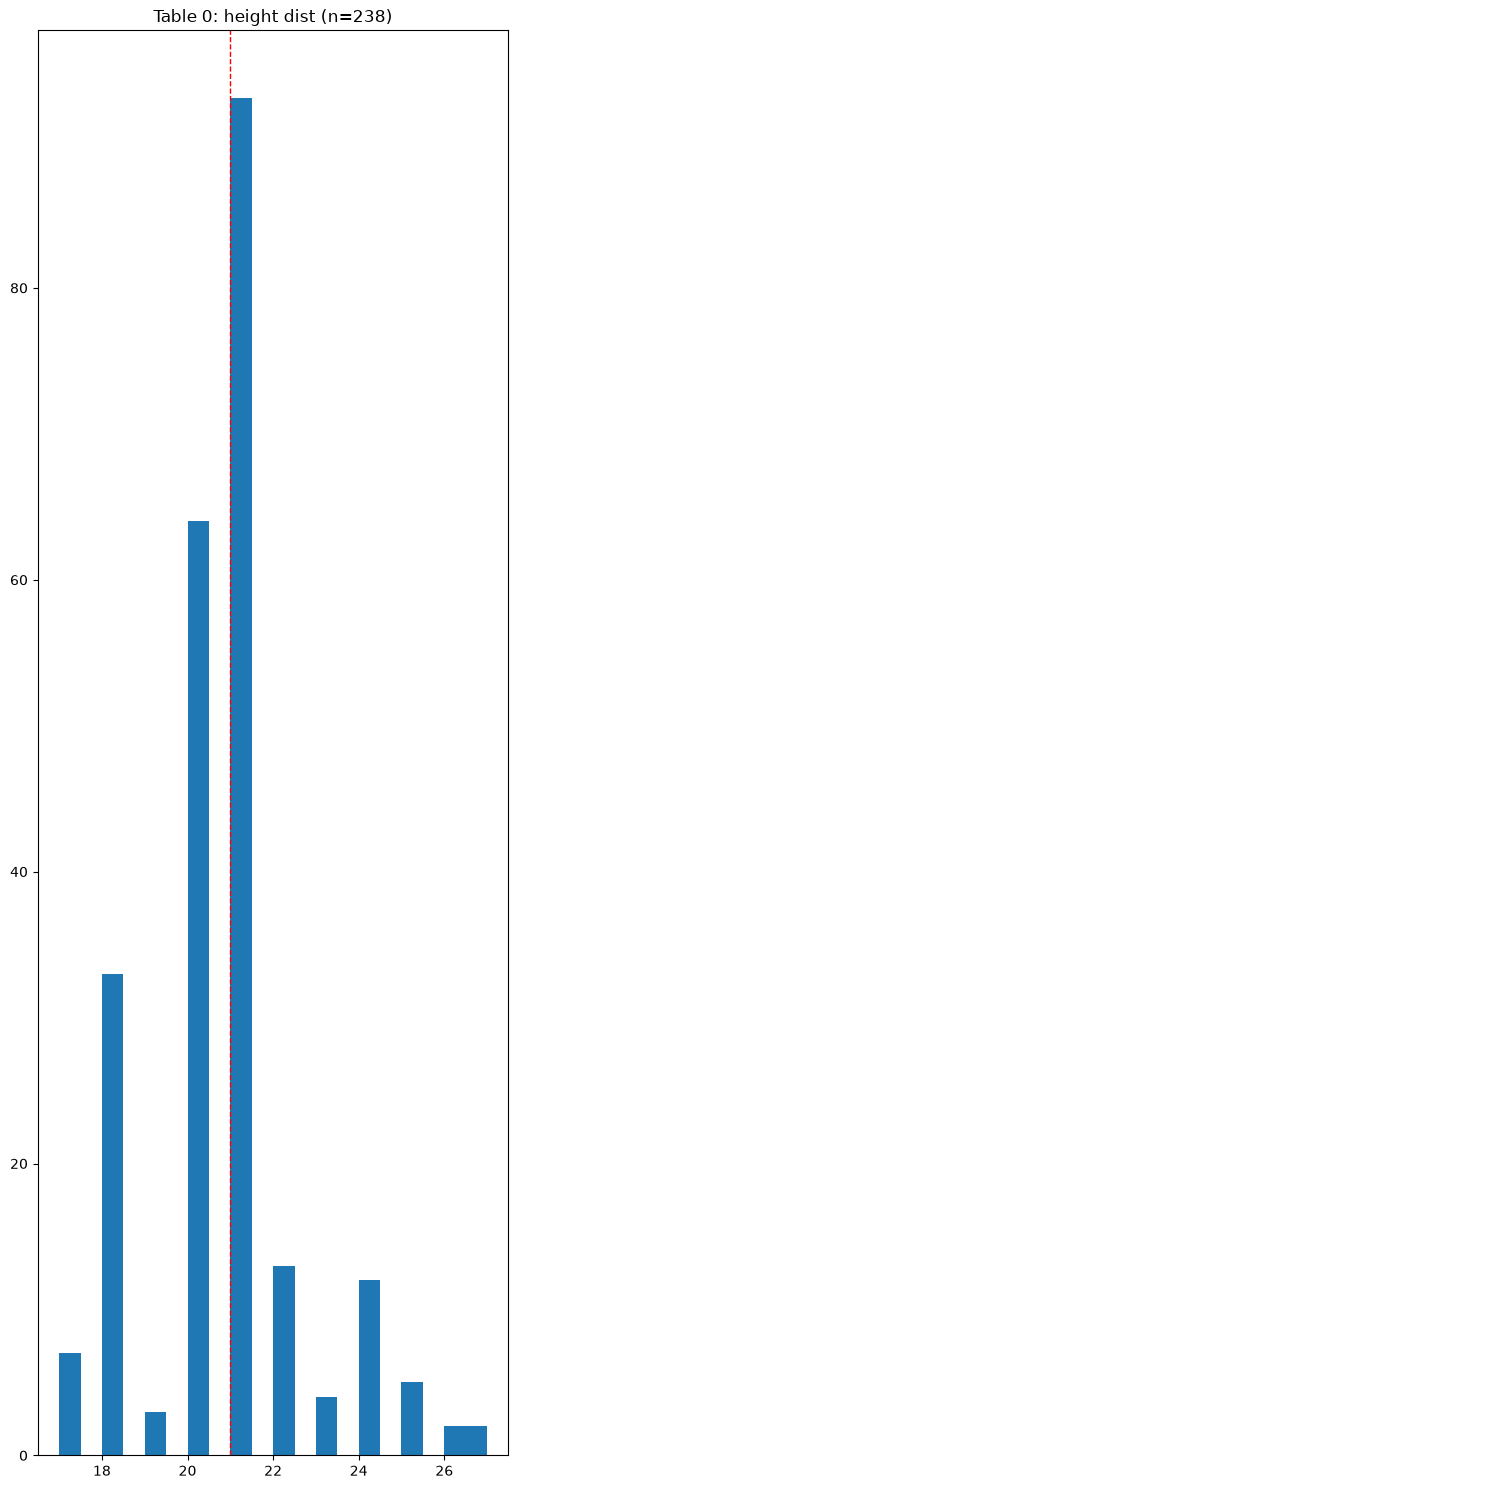

In [41]:
import numpy as np

from vision_core.detector.table_detector import overlapping_bboxes, overlapping_heights

n = len(table_candidates)
cols = 3
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 15))
axes = np.atleast_1d(axes).ravel()

list_median_heights = []

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))
    list_median_heights.append(median_height)

    ax = axes[i]
    ax.hist(heights, bins=20)
    # пунткирная линия медианы
    ax.axvline(median_height, color="r", linestyle="dashed", linewidth=1)
    ax.set_title(f"Table {i}: height dist (n={len(heights)})")

for j in range(n, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

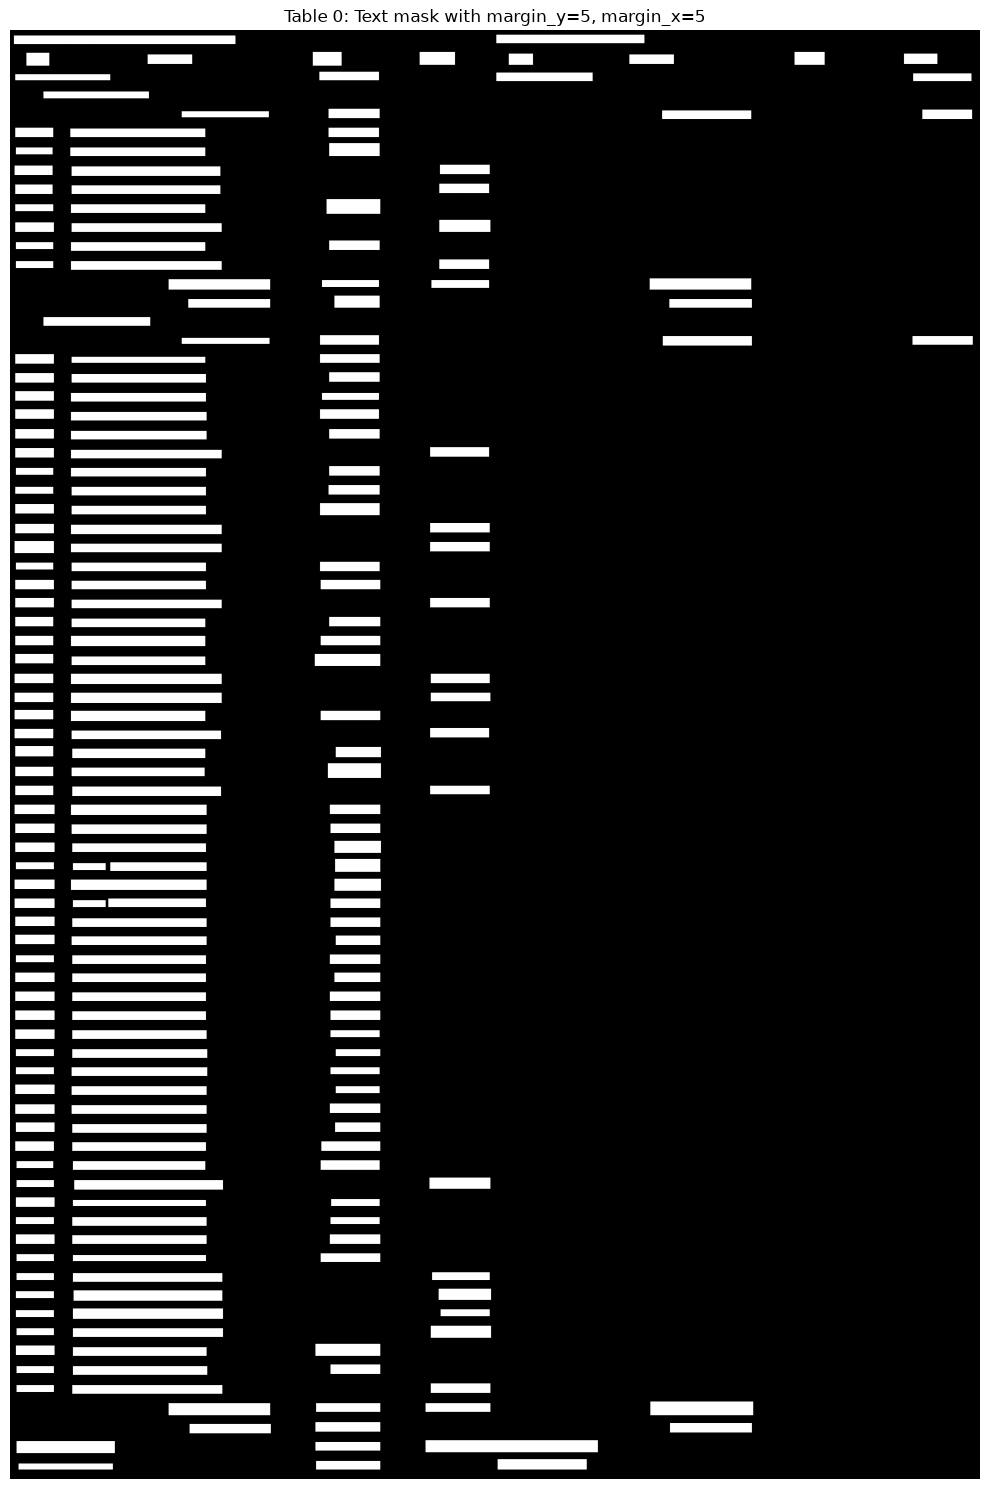

In [42]:
from vision_core.detector.table_detector import text_mask_inset

n = len(table_candidates)
fig, axes = plt.subplots(n, 1, figsize=(10, 15))
axes = np.atleast_1d(axes).ravel()

list_text_masks = []

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    mask = text_mask_inset(bbox, boxes, pix=5)
    list_text_masks.append(mask)

    ax = axes[i]
    ax.imshow(mask, cmap="gray", aspect="auto")
    ax.set_title(f"Table {i}: Text mask with margin_y={5}, margin_x={5}")
    ax.axis("off")

fig.tight_layout()
plt.show()

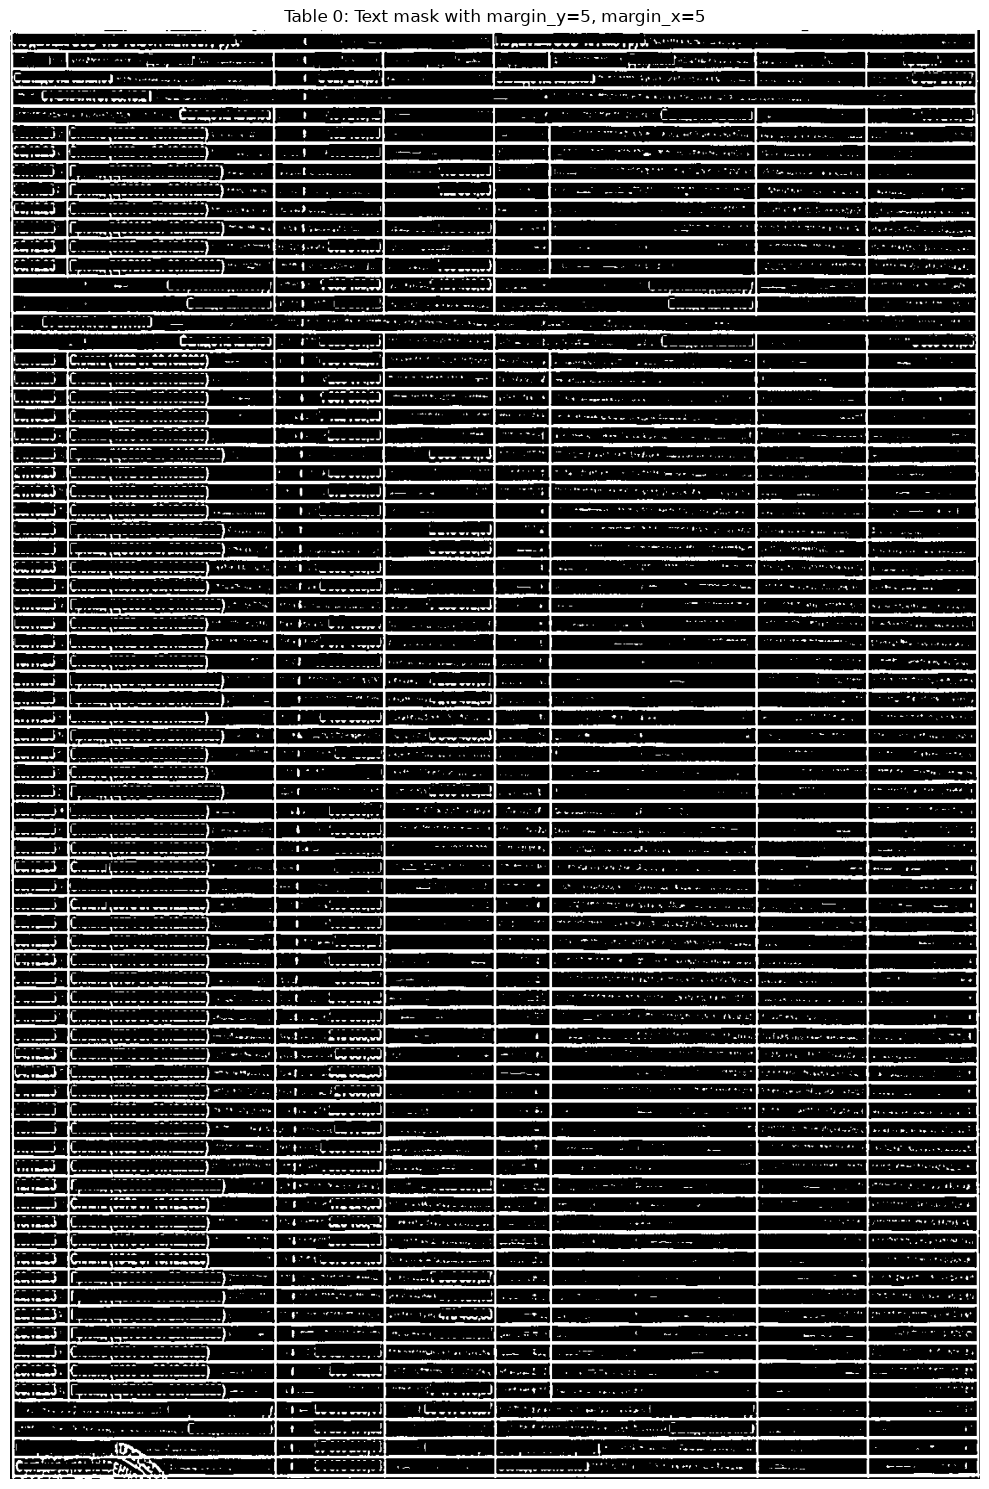

In [43]:
from vision_core.detector.table_detector import text_mask_inset
from vision_core.utils import image_utils

n = len(table_candidates)
fig, axes = plt.subplots(n, 1, figsize=(10, 15))
axes = np.atleast_1d(axes).ravel()

list_no_text = []

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    mask = text_mask_inset(bbox, boxes, pix=5)
    no_text = image_utils.subtract_mask(bbox.roi(detector._binary_img_clean_lines), mask)
    no_text = image_utils.get_mask(no_text, bbox.roi(detector._mask_fixed))
    list_no_text.append(no_text)

    ax = axes[i]
    ax.imshow(no_text, cmap="gray", aspect="auto")
    ax.set_title(f"Table {i}: Text mask with margin_y={5}, margin_x={5}")
    ax.axis("off")

fig.tight_layout()
plt.show()

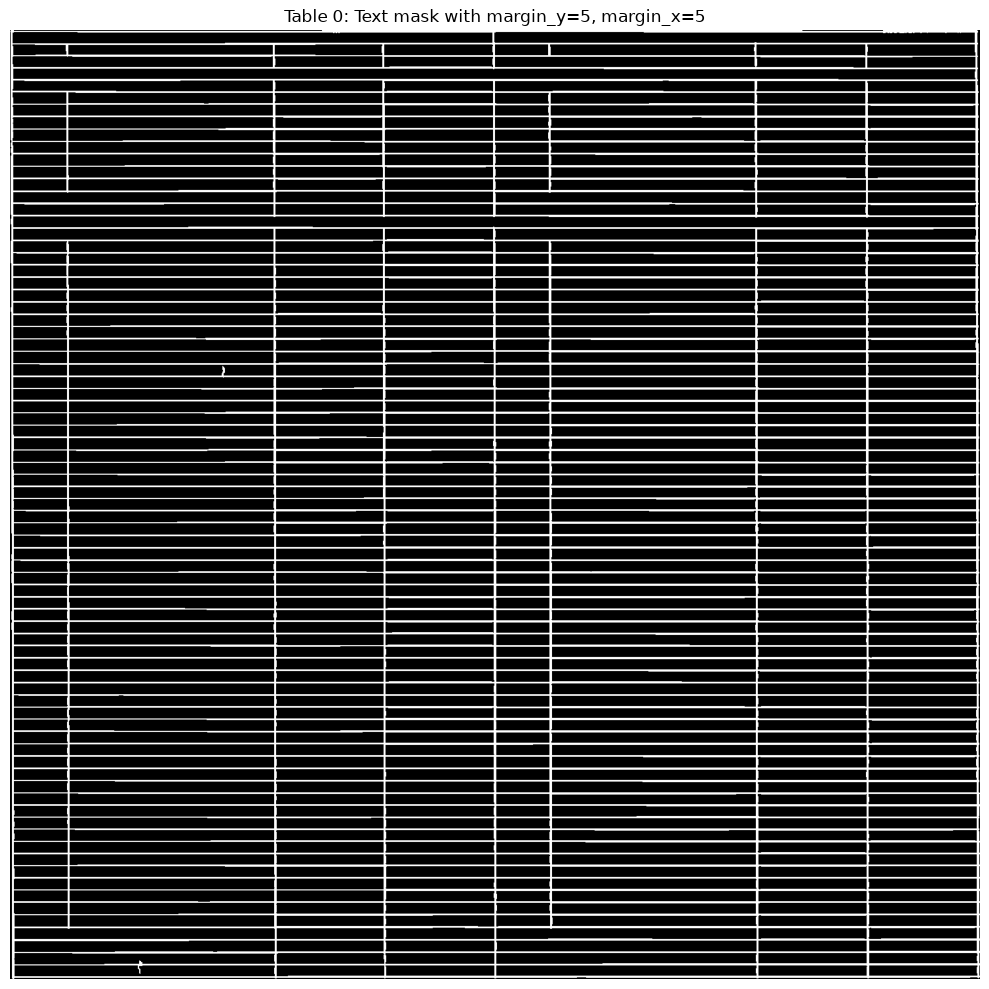

In [44]:
n = len(table_candidates)
fig, axes = plt.subplots(n, 1, figsize=(10, 10))
axes = np.atleast_1d(axes).ravel()


for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))

    mask, content_mask, v_mask, h_mask = detector._clean_mask_table(bbox, boxes, median_height)

    ax = axes[i]
    ax.imshow(mask, cmap="gray", aspect="auto")
    ax.set_title(f"Table {i}: Text mask with margin_y={5}, margin_x={5}")
    ax.axis("off")

fig.tight_layout()
plt.show()

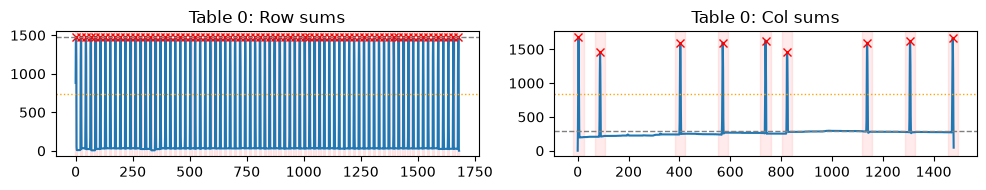

In [45]:
from vision_core.detector.table_detector import find_lines_with_edges, sum_pixel_axis
from scipy.signal import find_peaks

cols = 2
rows = n

fig, axes = plt.subplots(rows, cols, figsize=(10, 2 * rows))
axes = np.atleast_2d(axes)


def plot_peaks(ax, sums, peaks, distance, prominence_frac, edge_frac, title):
    candidate_peaks, _ = find_peaks(sums, distance=distance)
    baseline = np.median(sums[candidate_peaks]) if candidate_peaks.size > 0 else sums.max()
    edge_threshold = sums.max() * edge_frac

    ax.plot(sums)
    ax.plot(peaks, sums[peaks], "rx")
    ax.axhline(baseline, color="gray", linestyle="--", linewidth=1)
    ax.axhline(edge_threshold, color="orange", linestyle=":", linewidth=1)

    # полосы шириной distance вокруг каждого пика - зона минимального расстояния
    for p in peaks:
        ax.axvspan(p - distance / 2, p + distance / 2, color="red", alpha=0.08)

    ax.set_title(title)


for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))

    mask, content_mask, v_mask, h_mask = detector._clean_mask_table(bbox, boxes, median_height)
    row_pix = sum_pixel_axis(mask, axis=1)
    col_pix = sum_pixel_axis(mask, axis=0)

    row_distance, row_prom, row_edge = 10, 0.3, 0.5
    col_distance, col_prom, col_edge = 40, 0.3, 0.5

    row_peaks = find_lines_with_edges(
        row_pix, distance=row_distance, prominence_frac=row_prom, edge_check_width=5, edge_frac=row_edge
    )
    col_peaks = find_lines_with_edges(
        col_pix, distance=col_distance, prominence_frac=col_prom, edge_check_width=5, edge_frac=col_edge
    )

    plot_peaks(axes[i, 0], row_pix, row_peaks, row_distance, row_prom, row_edge, f"Table {i}: Row sums")
    plot_peaks(axes[i, 1], col_pix, col_peaks, col_distance, col_prom, col_edge, f"Table {i}: Col sums")

fig.tight_layout()
plt.show()


Table 0: row_ys=78, col_xs=9


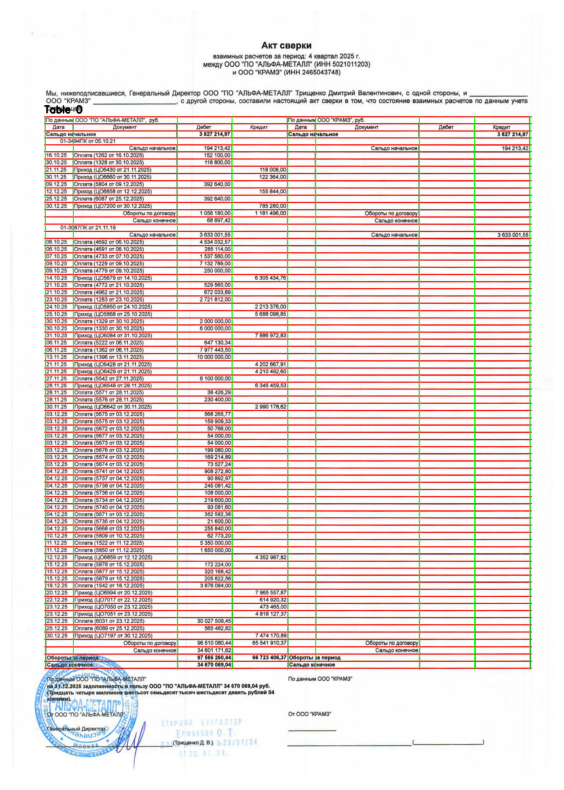

In [46]:
vis_grid = img.copy()

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))

    mask, content_mask, v_mask, h_mask = detector._clean_mask_table(bbox, boxes, median_height)
    row_ys, col_xs = detector._build_grid(mask, median_height)
    print(f"Table {i}: row_ys={len(row_ys)}, col_xs={len(col_xs)}")
    x, y = int(bbox.x_min), int(bbox.y_min)
    crop_h, crop_w = int(bbox.height), int(bbox.width)

    for ly in row_ys:
        cv2.line(vis_grid, (x, y + ly), (x + crop_w, y + ly), (255, 0, 0), 2)
    for lx in col_xs:
        cv2.line(vis_grid, (x + lx, y), (x + lx, y + crop_h), (0, 255, 0), 2)
    cv2.putText(vis_grid, f"Table {i}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 3)


plt.figure(figsize=(10, 10))
plt.imshow(vis_grid)
plt.axis("off")
plt.show()

In [47]:
from PIL import Image, ImageDraw, ImageFont

from vision_core.detector.table_detector import (
    assign_blobs_to_cells,
    build_merged_regions,
    build_table_entity,
    detect_horizontal_borders,
    detect_vertical_borders,
    find_reocr_cells,
)

base = Image.fromarray(img.copy()).convert("RGBA")
overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)
font = ImageFont.load_default(size=16)

for i, bbox in enumerate(table_candidates):
    boxes = overlapping_bboxes(bbox, detector.ocr_bboxes, min_overlap_ratio=0.6)
    heights = overlapping_heights(boxes)

    if not heights:
        continue

    median_height = float(np.median(heights))

    mask, content_mask, v_mask, h_mask = detector._clean_mask_table(bbox, boxes, median_height)
    row_ys, col_xs = detector._build_grid(mask, median_height)

    is_vborder = detect_vertical_borders(v_mask, row_ys, col_xs, tolerance=20, prominence_frac=0.3)
    is_hborder = detect_horizontal_borders(h_mask, row_ys, col_xs, tolerance=20, prominence_frac=0.3)

    n_rows = len(row_ys) - 1
    n_cols = len(col_xs) - 1

    np.set_printoptions(threshold=np.inf)

    for i, (x, v) in enumerate(zip(col_xs, is_vborder[0])):
        print(i, x, v)

    print(row_ys)
    print(median_height)

    strip = mask[0:33, :].sum(axis=0)
    print("max:", strip.max(), "threshold(0.2):", strip.max() * 0.2)
    print("around 722:", strip[702:743])
    print("around 1133:", strip[1113:1154])

    labels = build_merged_regions(is_vborder, is_hborder, n_rows, n_cols, mode="col")
    table = build_table_entity(bbox, labels, row_ys, col_xs, f"{i}")
    cell_ocr = assign_blobs_to_cells(table.cells, ocr_results, min_overlap_ratio=0.1, confidence_threshold=0.4)
    reocr_cells_list = find_reocr_cells(table.cells, cell_ocr, min_containment_ratio=0.7, min_overlap_ratio=0.1)
    reocr_ids = {id(c) for c in reocr_cells_list}

    print(f"Table {i}: {len(reocr_cells_list)} / {len(table.cells)} cells flagged for re-OCR")

    labels = build_merged_regions(is_vborder, is_hborder, n_rows, n_cols, mode=detector.cfg.mode_merge_cells)
    print(labels[0])

    for cell in table.cells:
        x0, y0, x1, y1 = cell.bbox.to_tuple()
        if id(cell) in reocr_ids:
            draw.rectangle([x0, y0, x1, y1], outline=(255, 0, 0, 255), fill=(255, 0, 0, 90), width=2)

    for b in boxes:
        draw.rectangle([b.x_min, b.y_min, b.x_max, b.y_max], outline=(0, 0, 255, 255), width=1)


vis_reocr = Image.alpha_composite(base, overlay).convert("RGB")
# display(vis_reocr)

0 3 True
1 88 False
2 404 False
3 570 False
4 739 True
5 824 False
6 1139 False
7 1307 False
8 1475 True
[   2   23   45   66   87  108  130  152  174  196  218  240  262  284
  306  328  350  371  393  415  437  459  481  503  524  546  568  591
  613  634  656  677  699  721  743  765  786  808  829  850  872  894
  917  938  960  982 1004 1025 1047 1069 1090 1112 1134 1156 1177 1199
 1220 1242 1264 1286 1308 1329 1352 1373 1394 1415 1437 1459 1480 1502
 1523 1545 1567 1589 1612 1634 1656 1677]
21.0
max: 8415 threshold(0.2): 1683.0
around 722: [1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785
 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785
 1785 1785 1785 1785 1785 1785 7905 8415 8415 4080 1785 1530 1530]
around 1133: [1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785
 1785 1785 1785 1785 1785 1785 1785 1785 2550 4080 4080 4080 1785 1785
 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785 1785]
Table 8: 15 / 616

Resized image size (4486x64) exceeds max_side_limit of 4000. Resizing to fit within limit.


R0:C0 - По даННЫм ООО "ПО"АЛЬФА-МЕТАЛЛ", руб.
R0:C4 - По данным ООО "КРАМЗ". руб.
R1:C0 - Дата
R1:C1 - Документ
R1:C2 - Дебет
R1:C3 - Кредит
R1:C4 - Дата
R1:C5 - Документ
R1:C6 - Дебет
R1:C7 - Кредит
R2:C0 - Сальдо начальное
R2:C2 - 3 827 214,97
R2:C3 - 
R2:C4 - Сальдо начальное
R2:C6 - 
R2:C7 - 3 827 214,97
R3:C0 - 01-3494PK OT 05.10.21
R4:C0 - Сальдо начальное
R4:C2 - 194213,42
R4:C3 - 
R4:C4 - Сальдо начальное
R4:C6 - 
R4:C7 - 194213,42
R5:C0 - 16.10.25
R5:C1 - ОПлата (1262 от 16.10.2025)
R5:C2 - 152100.00
R5:C3 - 
R5:C4 - 
R5:C5 - 
R5:C6 - 
R5:C7 - 
R6:C0 - 30.10.25
R6:C1 - Оплата (1328 от 30.10.2025)
R6:C2 - 118 800,00
R6:C3 - 
R6:C4 - 
R6:C5 - 
R6:C6 - 
R6:C7 - 
R7:C0 - 21.11.25
R7:C1 - Приход (LО6430 от 21.11.2025)
R7:C2 - 
R7:C3 - 118008,00
R7:C4 - 
R7:C5 - 
R7:C6 - 
R7:C7 - 
R8:C0 - 30.11.25
R8:C1 - Приход (ЦО6660 от 30.11.2025)
R8:C2 - 
R8:C3 - 122364.00
R8:C4 - 
R8:C5 - 
R8:C6 - 
R8:C7 - 
R9:C0 - 09.12.25
R9:C1 - Оплата(5804 от 09.12.2025)
R9:C2 - 392640.00
R9:C3 - 
R9:C4 - 

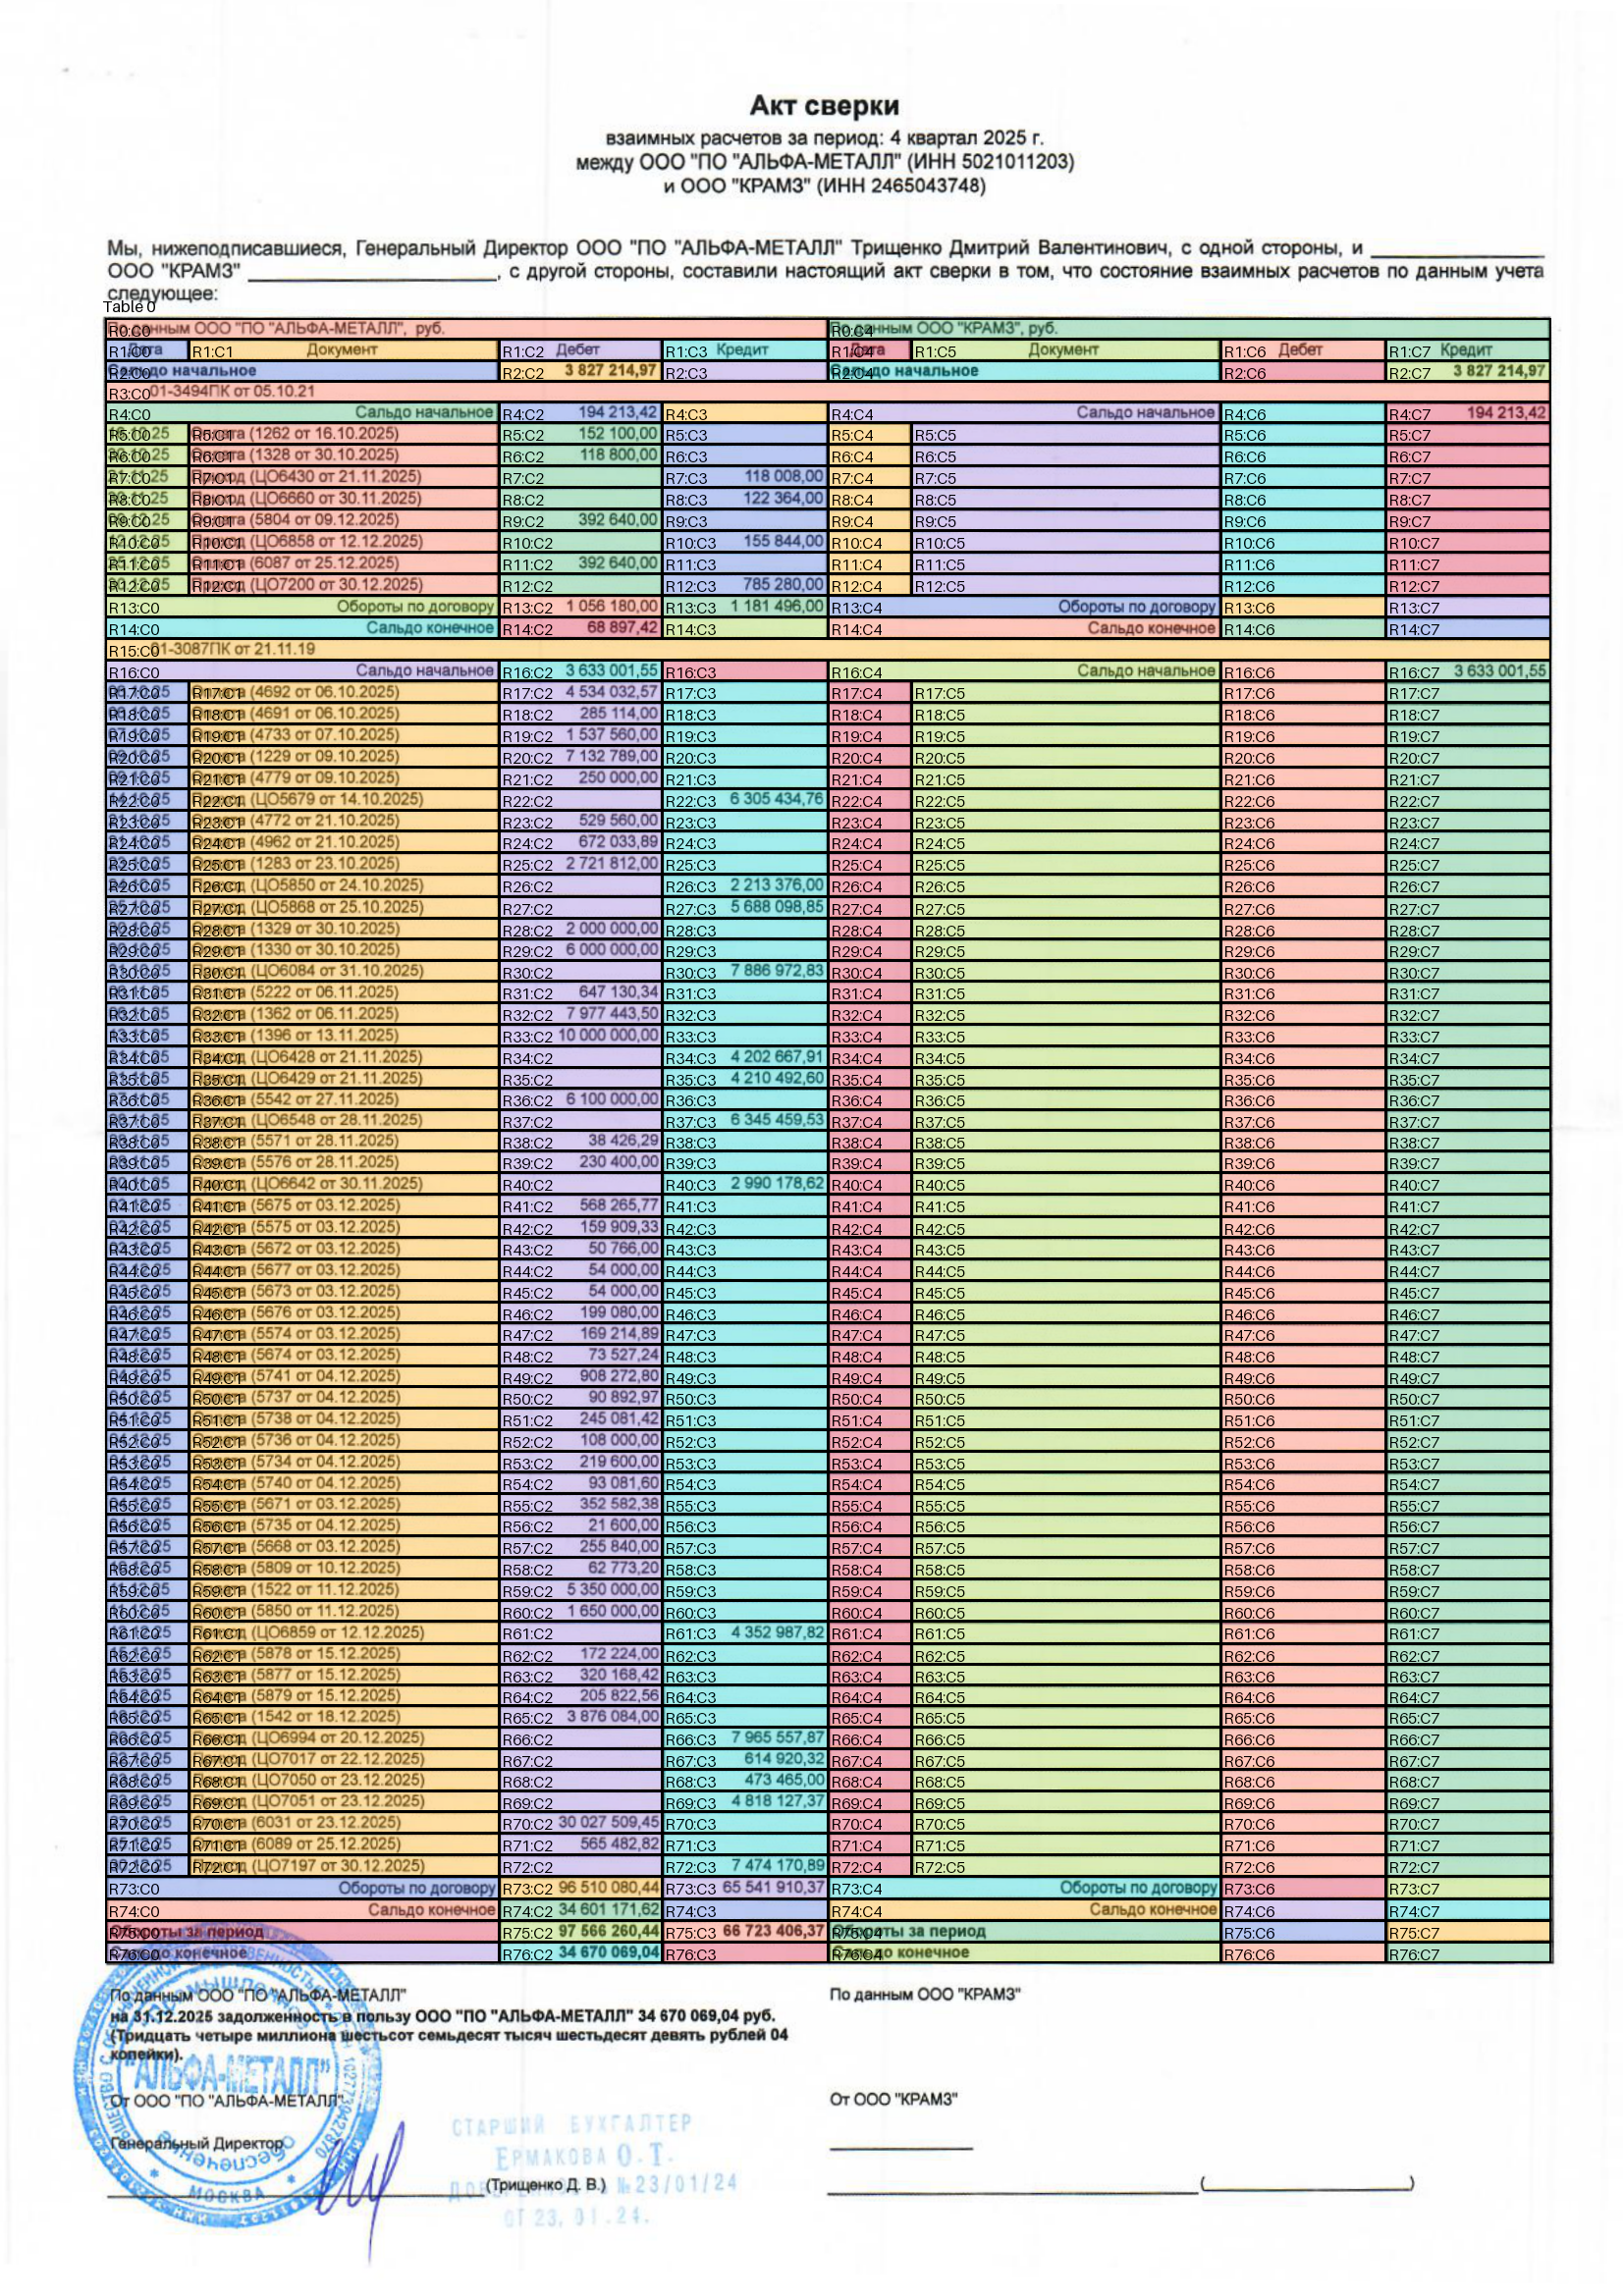

In [48]:
from PIL import Image, ImageDraw, ImageFont

list_tables = detector.detect_tables(img, ocr_results)

palette = [
    (255, 99, 71),
    (60, 179, 113),
    (65, 105, 225),
    (255, 165, 0),
    (147, 112, 219),
    (0, 206, 209),
    (220, 20, 60),
    (154, 205, 50),
]

base = Image.fromarray(img.copy()).convert("RGBA")
overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)
font = ImageFont.load_default(size=16)

for table in list_tables:
    for idx, cell in enumerate(table.cells):
        x0, y0, x1, y1 = cell.bbox.to_tuple()
        r, g, b = palette[idx % len(palette)]
        draw.rectangle([x0, y0, x1, y1], outline=(0, 0, 0, 255), width=2, fill=(r, g, b, 90))
        draw.text((x0 + 3, y0 + 3), f"R{cell.row}:C{cell.col}", fill=(0, 0, 0, 255), font=font)

        text = (cell.value or "").replace("\n", " / ")
        print(f"R{cell.row}:C{cell.col} - {text}")

    draw.text((int(table.bbox.x_min), int(table.bbox.y_min) - 20), f"Table {table.id}", fill=(0, 0, 0, 255), font=font)

vis_final = Image.alpha_composite(base, overlay).convert("RGB")
display(vis_final)
